# 📊 STB & STV ADR- Analisis de LOGS  

**Objetivo:** 
1. Detectar picos (Z-score estadístico)
2. Top 10 global
3. Top 10 por cada pico
4. Top 10 consolidado de picos
5. Market Basket (correlaciones)


El TOP 10 muestra detalles WEF (warning,error,fatals) de la propia muestra del log, el log representa el camino(path) del ticket reportado
NO busca crashes/errores en  específico - solo muestra Top 10s y patrones, asi como picos/outliners en los datos

**Componentes:**
- ✅ Parsing de logs con regex
- ✅ Agrupación temporal (60s)
- ✅ Counter WEF (Warnings, Errors, Fatals)
- ✅ Feature Engineering (rates, rolling, temporal)
- ✅ Reglas de Asociación (Market Basket - Apriori)
- ✅ Visualizaciones TOP 10 componentes afectados

**Output:**
- DataFrame con ~50 features → `stb_top_10_affected.csv`
- Plots → `data/plots/`
- PDF → `data/pdfs/report_date.pdf`

**Autor:** Alberto - Senior Tester  auto & Ml
**Fecha:** Marzo 2026  
**Versión:** 1.0
Cuaderno para analizar logs dispositivos STB ADR & STV ADR
AT


In [25]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 
import re
from datetime import datetime

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet

from typing import List, Dict, Tuple
import warnings

import os


warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

OUTPUT_DIR= "../../data/processed_logs"
PLOTS_DIR= "../../data/plots"
PDFS_DIR= "../../data/pdfs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(PDFS_DIR, exist_ok=True)


#configuración general
#log_file = "/home/at1/Desktop/qa-predictive-analytics/data/raw_logs/stb/7.3.2_v/hisense_crash_pe.txt"
log_file = "/home/at1/Desktop/datos_stb/logsanalisis/LOGS_SONY_3.4.0_RELEASE.txt"
DEGRADATION_THRESHOLD_ERROR_RATE = 0.06
DEGRADATION_THRESHOLD_FATAL = 1


# PARÁMETROS (ajustables después de ver varios logs)
ZSCORE_THRESHOLD = 2.0  # Desviaciones estándar (2 = outliers estadísticos)
MIN_ERRORS_ABSOLUTO = 50  # Mínimo errors para evitar ruido
 
# Market Basket mejorado
MIN_SUPPORT_MB = 0.3  # Mínimo 30% de picos
MIN_CONFIDENCE_MB = 0.6  # 60% confianza
MIN_LIFT_MB = 1.2  # Lift > 1.2 = correlación real (no obvia)
 
FIGSIZE_LARGE = (16, 8)
MOSTRAR_TOP10_SIN_PICOS = True
 
print("✅ Configuración cargada")

✅ Configuración cargada


In [26]:
#procesamiento de logs


def read_log_file(filepath: str) -> list[dict[str, str,None]] | None:
    """Carga el archivo y retorna lista de líneas"""
    parsed_logs= []
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as raw_logs:
            for line in raw_logs:
                parsed_line = parse_line(line)
                
                if parsed_line:
                    parsed_line["time"] = time_rounded(parsed_line["time"])
                    parsed_logs.append(parsed_line)
            return parsed_logs        

    except Exception as e:
        print(f"Error al leer el archivo TXT : {e}")
        return None
    
def parse_line(line: str) -> dict[str, str | None] | None:
    """Parsea una línea de log y retorna un diccionario con los datos"""
    if not line:
        return None
    try:

        pattern = r'^(\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2}\.\d{3})\s+(\d+)\s+(\d+)\s+([VDIWEF])\s+([^:]+):\s+(.+)$'
        match = re.match(pattern, line)
        if match:
            result = {
                "date": match.group(1),
                "time": match.group(2),
                "pid": match.group(3),
                "tid": match.group(4),
                "level": match.group(5),
                "tag": match.group(6).strip(),
                "message": match.group(7)
            }
            message = result["message"]
            
            device_match = re.search(r'model[=:]["\']*([A-Z0-9_]+)["\']*', message, re.IGNORECASE)
            if device_match:
                result["device_model"] = device_match.group(1)
            
            firmware_match = re.search(r'firmware[=:\s]+["\']*([0-9.]+)["\']*', message, re.IGNORECASE)
            if firmware_match:
                result["firmware_version"] = firmware_match.group(1)
            
            version_match = re.search(r'(?:android|version)[=:\s]+["\']*([0-9.]+)["\']*', message, re.IGNORECASE)
            if version_match:
                result["android_version"] = version_match.group(1)
            return result

        pattern_b = r'^(\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2}\.\d{3})\s+([VDIWEF])/([^(]+)\(\s*(\d+)\):\s+(.+)$'
        match = re.match(pattern_b, line)
        
        if match:
            return {
                "date": match.group(1),
                "time": match.group(2),
                "level": match.group(3),
                "tag": match.group(6).strip(),
                "pid": match.group(5).strip(),
                "tid": match.group(5).strip(),  # No hay TID en formato B, usar PID
                "message": match.group(6)
            }
        
        # No match con ningún formato
        return None   
    except Exception as e:
        print(f"Error al parsear la línea: {e}")
        return None
    
def time_rounded(parsed_line: str) -> str:
    """corta el tiempo a minutos"""
    time_minutes = datetime.strptime(parsed_line, "%H:%M:%S.%f")
    time_minutes = time_minutes.replace(second=0, microsecond=0).strftime("%H:%M")
    return time_minutes

def group_by_60s(parsed_logs: list[dict]) -> dict:
    logs_by_minute = {}
    for log in parsed_logs:
        if log['time'] not in logs_by_minute:
            logs_by_minute[log['time']] = []
        logs_by_minute[log['time']].append(log)
    return logs_by_minute

def get_claro_pids(logs_by_minute: dict) -> set:
    pattern = r'(?i)(claro|amx\.?|clarotv|launcher)'
    pids_claro = []
    for minute, logs in logs_by_minute.items():
        for log in logs:
            if re.search(pattern, log['message']):
                pids_claro.append(log['pid'])
    return set(pids_claro)

In [27]:
# ============================================================================
# DETECCIÓN DE PICOS (Z-SCORE)
# ============================================================================
def detect_picos(df, zscore_threshold=ZSCORE_THRESHOLD, min_errors=MIN_ERRORS_ABSOLUTO):
    """
    Detecta picos usando Z-score estadístico
    
    Z-score = (valor - media) / desviación
    Si Z > 2 → outlier (pico)
    """
    
    by_minute = df.groupby('time').agg({
        'level': [('total', 'count'), ('errors', lambda x: (x == 'E').sum())]
    })
    by_minute.columns = ['total', 'errors']
    by_minute = by_minute.reset_index()
    
    mean_errors = by_minute['errors'].mean()
    std_errors = by_minute['errors'].std()
    
    if std_errors == 0:
        return pd.DataFrame()
    
    by_minute['z_score'] = (by_minute['errors'] - mean_errors) / std_errors
    
    picos = by_minute[
        (by_minute['z_score'] > zscore_threshold) &
        (by_minute['errors'] >= min_errors)
    ].copy()
    
    return picos.sort_values('errors', ascending=False)
 
print("✅ Detección de picos cargada")
 

✅ Detección de picos cargada


In [28]:
# ============================================================================
# FUNCIONES CORREGIDAS CON ESTADÍSTICAS WEF COMPLETAS
# ============================================================================
 
def generate_top_analysis(df, pids_claro, label=""):
    """Genera Top 10s completos (ALL y CLARO)"""
    df['is_claro'] = df['pid'].isin(pids_claro)
    
    tops = {'label': label}
    
    # ========================================================================
    # TAGS - ALL y CLARO
    # ========================================================================
    tops['top_tags_all'] = df['tag'].value_counts().head(10)
    tops['top_tags_claro'] = df[df['is_claro']]['tag'].value_counts().head(10)
    
    # ========================================================================
    # TAGS CON ERRORS - ALL y CLARO
    # ========================================================================
    tops['top_error_tags_all'] = df[df['is_error']]['tag'].value_counts().head(10)
    tops['top_error_tags_claro'] = df[df['is_claro'] & df['is_error']]['tag'].value_counts().head(10)
    
    # ========================================================================
    # MENSAJES DE ERROR - ALL y CLARO
    # ========================================================================
    tops['top_errors_all'] = df[df['is_error']]['message'].value_counts().head(10)
    tops['top_errors_claro'] = df[df['is_claro'] & df['is_error']]['message'].value_counts().head(10)
    
    # ========================================================================
    # MENSAJES DE WARNING - ALL y CLARO
    # ========================================================================
    tops['top_warnings_all'] = df[df['is_warning']]['message'].value_counts().head(10)
    tops['top_warnings_claro'] = df[df['is_claro'] & df['is_warning']]['message'].value_counts().head(10)
    
    # ========================================================================
    # MENSAJES DE FATAL - ALL y CLARO
    # ========================================================================
    tops['top_fatals_all'] = df[df['is_fatal']]['message'].value_counts().head(10)
    tops['top_fatals_claro'] = df[df['is_claro'] & df['is_fatal']]['message'].value_counts().head(10)
    
    # ========================================================================
    # PIDs
    # ========================================================================
    tops['top_pids'] = df['pid'].value_counts().head(10)
    
    # ========================================================================
    # MINUTOS CON ERRORES (solo en análisis global)
    # ========================================================================
    if not label or "GLOBAL" in label:
        tops['top_error_minutes'] = df[df['is_error']].groupby('time').size().sort_values(ascending=False).head(10)
    
    return tops
 
 

def print_resumen_general(df, pids_claro):
    """Resumen WEF con totales y promedios"""
    
    total_logs = len(df)
    total_errors = df['is_error'].sum()
    total_warnings = df['is_warning'].sum()
    total_fatals = df['is_fatal'].sum()
    
    df_claro = df[df['pid'].isin(pids_claro)]
    total_logs_claro = len(df_claro)
    total_errors_claro = df_claro['is_error'].sum()
    total_warnings_claro = df_claro['is_warning'].sum()
    total_fatals_claro = df_claro['is_fatal'].sum()
    
    total_minutos = len(df['time'].unique())
    avg_errors_min = total_errors / total_minutos if total_minutos > 0 else 0
    avg_warnings_min = total_warnings / total_minutos if total_minutos > 0 else 0
    avg_fatals_min = total_fatals / total_minutos if total_minutos > 0 else 0
    
    print("\n" + "="*80)
    print("RESUMEN GENERAL")
    print("="*80)
    
    print(f"\nALL:")
    print(f"Logs: {total_logs:,} | Errors: {total_errors:,} | Warnings: {total_warnings:,} | Fatals: {total_fatals:,}")
    
    print(f"\nCLARO:")
    print(f"Logs: {total_logs_claro:,} | Errors: {total_errors_claro:,} | Warnings: {total_warnings_claro:,} | Fatals: {total_fatals_claro:,}")
    
    print(f"\nPromedios ({total_minutos} minutos):")
    print(f"Errors/min: {avg_errors_min:.1f} | Warnings/min: {avg_warnings_min:.1f} | Fatals/min: {avg_fatals_min:.1f}")
    
    print("="*80)
 
 
# ============================================================================
# FUNCIÓN 2: print_top_analysis (sin emojis)
# ============================================================================
 
def print_top_analysis(tops, compact=False):
    """Imprime Top 10s con separación ALL vs CLARO"""
    label = tops.get('label', '')
    print("\n" + "="*80)
    print(f"{label}" if label else "ANÁLISIS DE TOPS")
    print("="*80)
    
    limit = 3 if compact else 10
    
    # TOP TAGS
    print(f"\nTOP {limit} TAGS (ALL - incluye sistema Android):")
    for tag, count in list(tops['top_tags_all'].items())[:limit]:
        print(f"   {tag}: {count:,}")
    
    if not compact and len(tops.get('top_tags_claro', [])) > 0:
        print(f"\nTOP {limit} TAGS (SOLO CLARO):")
        for tag, count in list(tops['top_tags_claro'].items())[:limit]:
            print(f"   {tag}: {count:,}")
    
    # TOP TAGS CON ERRORS
    print(f"\nTOP {limit} TAGS CON ERRORES (ALL):")
    for tag, count in list(tops['top_error_tags_all'].items())[:limit]:
        print(f"   {tag}: {count:,}")
    
    if not compact and len(tops.get('top_error_tags_claro', [])) > 0:
        print(f"\nTOP {limit} TAGS CON ERRORES (SOLO CLARO):")
        for tag, count in list(tops['top_error_tags_claro'].items())[:limit]:
            print(f"   {tag}: {count:,}")
    
    # TOP MENSAJES DE ERROR
    print(f"\nTOP {limit} MENSAJES DE ERROR (ALL):")
    for msg, count in list(tops['top_errors_all'].items())[:limit]:
        print(f"   [{count:,}x] {msg[:60]}...")
    
    if not compact and len(tops.get('top_errors_claro', [])) > 0:
        print(f"\nTOP {limit} MENSAJES DE ERROR (SOLO CLARO):")
        for msg, count in list(tops['top_errors_claro'].items())[:limit]:
            print(f"   [{count:,}x] {msg[:60]}...")
    
    # TOP MENSAJES DE WARNING
    if not compact and len(tops['top_warnings_all']) > 0:
        print(f"\nTOP {limit} MENSAJES DE WARNING (ALL):")
        for msg, count in list(tops['top_warnings_all'].items())[:limit]:
            print(f"   [{count:,}x] {msg[:60]}...")
    
    if not compact and len(tops.get('top_warnings_claro', [])) > 0:
        print(f"\nTOP {limit} MENSAJES DE WARNING (SOLO CLARO):")
        for msg, count in list(tops['top_warnings_claro'].items())[:limit]:
            print(f"   [{count:,}x] {msg[:60]}...")
    
    # TOP MENSAJES DE FATAL
    if not compact and len(tops['top_fatals_all']) > 0:
        print(f"\nTOP {limit} MENSAJES DE FATAL (ALL):")
        for msg, count in list(tops['top_fatals_all'].items())[:limit]:
            print(f"   [{count:,}x] {msg[:60]}...")
    
    if not compact and len(tops.get('top_fatals_claro', [])) > 0:
        print(f"\nTOP {limit} MENSAJES DE FATAL (SOLO CLARO):")
        for msg, count in list(tops['top_fatals_claro'].items())[:limit]:
            print(f"   [{count:,}x] {msg[:60]}...")
    
    # TOP MINUTOS CON ERRORES
    if not compact and 'top_error_minutes' in tops:
        print(f"\nTOP {limit} MINUTOS CON ERRORES:")
        for time, count in list(tops['top_error_minutes'].items())[:limit]:
            print(f"   {time}: {count:,} errors")
    
    print("="*80)

def consolidate_tops(tops_list):
    """Consolida múltiples Top 10s en uno solo (suma)"""
    consolidated = {'label': 'CONSOLIDADO (todos los picos)'}
    
    # TAGS - ALL
    all_tags = pd.concat([t['top_tags_all'] for t in tops_list])
    consolidated['top_tags_all'] = all_tags.groupby(all_tags.index).sum().sort_values(ascending=False).head(10)
    
    # TAGS - CLARO
    tags_claro_list = [t.get('top_tags_claro', pd.Series(dtype=int)) for t in tops_list if len(t.get('top_tags_claro', [])) > 0]
    if len(tags_claro_list) > 0:
        all_tags_claro = pd.concat(tags_claro_list)
        consolidated['top_tags_claro'] = all_tags_claro.groupby(all_tags_claro.index).sum().sort_values(ascending=False).head(10)
    else:
        consolidated['top_tags_claro'] = pd.Series(dtype=int)
    
    # TAGS CON ERRORS - ALL
    all_error_tags = pd.concat([t['top_error_tags_all'] for t in tops_list])
    consolidated['top_error_tags_all'] = all_error_tags.groupby(all_error_tags.index).sum().sort_values(ascending=False).head(10)
    
    # TAGS CON ERRORS - CLARO
    error_tags_claro_list = [t.get('top_error_tags_claro', pd.Series(dtype=int)) for t in tops_list if len(t.get('top_error_tags_claro', [])) > 0]
    if len(error_tags_claro_list) > 0:
        all_error_tags_claro = pd.concat(error_tags_claro_list)
        consolidated['top_error_tags_claro'] = all_error_tags_claro.groupby(all_error_tags_claro.index).sum().sort_values(ascending=False).head(10)
    else:
        consolidated['top_error_tags_claro'] = pd.Series(dtype=int)
    
    # MENSAJES DE ERROR - ALL
    all_errors = pd.concat([t['top_errors_all'] for t in tops_list])
    consolidated['top_errors_all'] = all_errors.groupby(all_errors.index).sum().sort_values(ascending=False).head(10)
    
    # MENSAJES DE ERROR - CLARO
    errors_claro_list = [t.get('top_errors_claro', pd.Series(dtype=int)) for t in tops_list if len(t.get('top_errors_claro', [])) > 0]
    if len(errors_claro_list) > 0:
        all_errors_claro = pd.concat(errors_claro_list)
        consolidated['top_errors_claro'] = all_errors_claro.groupby(all_errors_claro.index).sum().sort_values(ascending=False).head(10)
    else:
        consolidated['top_errors_claro'] = pd.Series(dtype=int)
    
    # MENSAJES DE WARNING - ALL
    all_warnings = pd.concat([t['top_warnings_all'] for t in tops_list])
    consolidated['top_warnings_all'] = all_warnings.groupby(all_warnings.index).sum().sort_values(ascending=False).head(10)
    
    # MENSAJES DE WARNING - CLARO
    warnings_claro_list = [t.get('top_warnings_claro', pd.Series(dtype=int)) for t in tops_list if len(t.get('top_warnings_claro', [])) > 0]
    if len(warnings_claro_list) > 0:
        all_warnings_claro = pd.concat(warnings_claro_list)
        consolidated['top_warnings_claro'] = all_warnings_claro.groupby(all_warnings_claro.index).sum().sort_values(ascending=False).head(10)
    else:
        consolidated['top_warnings_claro'] = pd.Series(dtype=int)
    
    # MENSAJES DE FATAL - ALL
    fatals_all_list = [t.get('top_fatals_all', pd.Series(dtype=int)) for t in tops_list if len(t.get('top_fatals_all', [])) > 0]
    if len(fatals_all_list) > 0:
        all_fatals = pd.concat(fatals_all_list)
        consolidated['top_fatals_all'] = all_fatals.groupby(all_fatals.index).sum().sort_values(ascending=False).head(10)
    else:
        consolidated['top_fatals_all'] = pd.Series(dtype=int)
    
    # MENSAJES DE FATAL - CLARO
    fatals_claro_list = [t.get('top_fatals_claro', pd.Series(dtype=int)) for t in tops_list if len(t.get('top_fatals_claro', [])) > 0]
    if len(fatals_claro_list) > 0:
        all_fatals_claro = pd.concat(fatals_claro_list)
        consolidated['top_fatals_claro'] = all_fatals_claro.groupby(all_fatals_claro.index).sum().sort_values(ascending=False).head(10)
    else:
        consolidated['top_fatals_claro'] = pd.Series(dtype=int)
    
    # PIDs
    all_pids = pd.concat([t['top_pids'] for t in tops_list])
    consolidated['top_pids'] = all_pids.groupby(all_pids.index).sum().sort_values(ascending=False).head(10)
    
    return consolidated



In [29]:

def create_basket_mejorado(df_picos, pids_claro):
    """Crea basket con categorías ESPECÍFICAS de negocio"""
    
    basket_data = []
    
    for time_key, df_minute in df_picos.groupby('time'):
        
        # Errors por tag específico
        authpii_errors = df_minute[(df_minute['tag']=='AuthPII') & (df_minute['is_error'])].shape[0]
        channel_errors = df_minute[(df_minute['tag']=='ChannelGroupRefreshWorker') & (df_minute['is_error'])].shape[0]
        location_errors = df_minute[(df_minute['tag']=='LocationServiceGeoCodeProvider') & (df_minute['is_error'])].shape[0]
        activitymgr_errors = df_minute[(df_minute['tag']=='ActivityManager') & (df_minute['is_error'])].shape[0]
        adr8_errors = df_minute[(df_minute['tag']=='Adr8OvpTabConfigRepo') & (df_minute['is_error'])].shape[0]
        
        # Mensajes específicos
        network_msgs = df_minute[df_minute['message'].str.contains('timeout|failed|network', case=False, na=False, regex=True)].shape[0]
        binder_msgs = df_minute[df_minute['message'].str.contains('Binder', case=False, na=False)].shape[0]
        
        # Fatals
        has_fatals = df_minute['is_fatal'].sum() > 0
        
        # PIDs Claro
        claro_active = df_minute['pid'].isin(pids_claro).sum() > 0
        
        # Total
        total_errors = df_minute['is_error'].sum()
        
        basket_data.append({
            'time': time_key,
            'authpii_problem': authpii_errors > 50,
            'channel_problem': channel_errors > 20,
            'location_problem': location_errors > 20,
            'activity_problem': activitymgr_errors > 30,
            'adr8_problem': adr8_errors > 20,
            'network_issue': network_msgs > 10,
            'binder_issue': binder_msgs > 15,
            'has_fatals': has_fatals,
            'critical_errors': total_errors > 300,
            'claro_active': claro_active
        })
    
    return pd.DataFrame(basket_data)
 
 
def apply_market_basket_mejorado(df_basket):
    """Market Basket con filtro de LIFT"""
    
    basket_cols = [c for c in df_basket.columns if c != 'time']
    df_binary = df_basket[basket_cols]
    
    try:
        freq = apriori(df_binary, min_support=MIN_SUPPORT_MB, use_colnames=True)
        
        if freq.empty:
            return None, None
        
        rules = association_rules(freq, metric="confidence", min_threshold=MIN_CONFIDENCE_MB)
        
        if rules.empty:
            return freq, None
        
        # FILTRO: Solo reglas con LIFT > min_lift (correlación real)
        rules_filtered = rules[rules['lift'] > MIN_LIFT_MB].copy()
        
        if rules_filtered.empty:
            print(f"⚠️  No hay reglas con lift > {MIN_LIFT_MB}")
            return freq, None
        
        print(f"✅ {len(rules_filtered)} reglas útiles (lift > {MIN_LIFT_MB})")
        
        return freq, rules_filtered
        
    except Exception as e:
        print(f"❌ Error: {e}")
        return None, None
 
 
def print_rules_mejorado(rules, top_n=5):
    """Imprime reglas con interpretación"""
    
    if rules is None or rules.empty:
        return
    
    print("\n" + "="*80)
    print("🔗 PATRONES ENCONTRADOS (Market Basket)")
    print("="*80)
    print("\n📊 Reglas ordenadas por LIFT (correlación más fuerte primero):\n")
    
    top_rules = rules.nlargest(top_n, 'lift')
    
    for idx, (_, r) in enumerate(top_rules.iterrows(), 1):
        ant = ', '.join(list(r['antecedents']))
        cons = ', '.join(list(r['consequents']))
        
        print(f"🔹 Regla #{idx}:")
        print(f"   SI: {ant}")
        print(f"   ENTONCES: {cons}")
        print(f"   • Confianza: {r['confidence']:.0%} | Lift: {r['lift']:.2f}x | Soporte: {r['support']:.0%}")
        print()
    
    print("="*80)
    print("💡 Lift > 1.2 = Correlación real (no coincidencia)")
    print("="*80)
 
print("✅ Market Basket mejorado cargado")




✅ Market Basket mejorado cargado


In [30]:
def plot_picos_detectados(picos_df):
    """Gráfica de barras de picos detectados (solo si hay 2+)"""
    if picos_df is None or len(picos_df) == 0:
        return
    
    # Solo mostrar si hay 2+ picos (1 pico no aporta info)
    if len(picos_df) < 2:
        print("ℹ️  Solo 1 pico detectado - gráfica omitida")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    times = picos_df['time'].tolist()
    errors = picos_df['errors'].tolist()
    z_scores = picos_df['z_score'].tolist()
    
    bars = ax.bar(range(len(times)), errors, color='red', alpha=0.7, edgecolor='darkred', linewidth=2)
    
    # Etiquetas con Z-score
    for i, (t, e, z) in enumerate(zip(times, errors, z_scores)):
        ax.text(i, e + 20, f'{t}\n{e:,} errors\nZ={z:.1f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Picos Detectados', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cantidad de Errors', fontsize=12, fontweight='bold')
    ax.set_title('🚨 Picos Detectados (Outliers Estadísticos)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(times)))
    ax.set_xticklabels([f'Pico #{i+1}' for i in range(len(times))])
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/02_picos_detectados.png", dpi=300, bbox_inches='tight')
    print(f"✅ Plot picos: {PLOTS_DIR}/02_picos_detectados.png")
    plt.show()
 
def plot_overview(df, picos_df=None):
    """EDA Visual - 4 gráficas principales con marcadores de picos"""
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE)
    fig.suptitle('📊 EDA Overview', fontsize=16, fontweight='bold')
    
    # 1. Distribución de Log Levels
    level_counts = df['level'].value_counts()
    colors = {'V':'green','D':'blue','I':'cyan','W':'orange','E':'red','F':'darkred'}
    bar_colors = [colors.get(l,'gray') for l in level_counts.index]
    
    axes[0,0].bar(level_counts.index, level_counts.values, color=bar_colors)
    axes[0,0].set_title('Distribución de Log Levels', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Cantidad')
    axes[0,0].grid(axis='y', alpha=0.3)
    
    for i, (level, count) in enumerate(level_counts.items()):
        axes[0,0].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    # 2. Top 10 Tags con Errores/Fatals
    error_tags = df[df['level'].isin(['E','F'])]['tag'].value_counts().head(10)
    if len(error_tags) > 0:
        axes[0,1].barh(range(len(error_tags)), error_tags.values, color='coral')
        axes[0,1].set_yticks(range(len(error_tags)))
        axes[0,1].set_yticklabels(error_tags.index, fontsize=8)
        axes[0,1].set_title('Top 10 Tags con Errores/Fatals', fontsize=12, fontweight='bold')
        axes[0,1].set_xlabel('Cantidad')
        axes[0,1].invert_yaxis()
        axes[0,1].grid(axis='x', alpha=0.3)
    
    # 3. Timeline Errors por minuto
    errors_by_time = df[df['level']=='E'].groupby('time').size()
    
    all_times = sorted(df['time'].unique())
    errors_series = errors_by_time.reindex(all_times, fill_value=0)
    
    x = range(len(all_times))
    axes[1,0].plot(x, errors_series.values, label='Errors', color='red', linewidth=2)
    
    if picos_df is not None and len(picos_df) > 0:
        pico_idx = [all_times.index(t) for t in picos_df['time'] if t in all_times]
        axes[1,0].scatter(pico_idx, [errors_series.iloc[i] for i in pico_idx],
                         color='red', s=200, marker='X', zorder=5, label='Picos')
    
    axes[1,0].set_title('Timeline Errors', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Tiempo (HH:MM)', fontsize=10)
    axes[1,0].set_ylabel('Cantidad de Errors', fontsize=10)
    
    # Mostrar timestamps reales (cada N minutos)
    num_ticks = min(10, len(all_times))
    tick_step = max(1, len(all_times) // num_ticks)
    tick_positions = list(range(0, len(all_times), tick_step))
    tick_labels = [all_times[i] for i in tick_positions]
    
    axes[1,0].set_xticks(tick_positions)
    axes[1,0].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)
    
    # 4. Top PIDs
    top_pids = df['pid'].value_counts().head(10)
    axes[1,1].barh(range(len(top_pids)), top_pids.values, color='skyblue')
    axes[1,1].set_yticks(range(len(top_pids)))
    axes[1,1].set_yticklabels(top_pids.index, fontsize=8)
    axes[1,1].set_title('Top 10 PIDs')
    axes[1,1].invert_yaxis()
    axes[1,1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/01_eda_overview.png", dpi=300, bbox_inches='tight')
    print(f"✅ Plot: {PLOTS_DIR}/01_eda_overview.png")
    plt.show()

In [31]:
def diagnostico(df, picos, pids_claro):
    """Diagnóstico completo basado en patrones verificados en logs reales"""
    
    print("\n" + "="*80)
    print("DIAGNÓSTICO")
    print("="*80)
    
    # ========================================================================
    # CASO 1: NO HAY PICOS (puede ser log normal o crash desde inicio)
    # ========================================================================
    if len(picos) == 0:
        print("\nLog estable - sin picos detectados")
        
        # Analizar TOP componentes con errores del log completo
        top_all = df[df['is_error']]['tag'].value_counts().head(5)
        
        if len(top_all) > 0:
            # Componente principal
            tag = top_all.index[0]
            count = top_all.values[0]
            
            from android_components_dict import get_component_info, is_system_noise
            info = get_component_info(tag)
            
            print(f"\nComponente más afectado: {tag} ({count:,} errors)")
            
            if info:
                print(f"Categoría: {info['categoria']}")
                print(f"Severidad típica: {info['severidad_tipica']}")
                
                if is_system_noise(tag):
                    print("\nNota: Este es ruido del sistema Android, no es culpable directo")
                else:
                    if 'errores_comunes' in info and len(info['errores_comunes']) > 0:
                        print(f"\nErrores comunes:")
                        for error in info['errores_comunes'][:2]:
                            print(f"  - {error}")
                    
                    if 'accion' in info:
                        print(f"\nAcción recomendada:")
                        print(f"  {info['accion']}")
                            
            # Top componentes Claro
            df_claro = df[df['pid'].isin(pids_claro)]
            top_claro = df_claro[df_claro['is_error']]['tag'].value_counts().head(5)
            
            if len(top_claro) > 0:
                print(f"\nComponentes de Claro afectados:")
                for i, (tag, count) in enumerate(list(top_claro.items())[:5], 1):
                    info = get_component_info(tag)
                    categoria = f"({info['categoria']})" if info else ""
                    print(f"  {i}. {tag}: {count:,} errors {categoria}")
        
        # Análisis técnico
        _check_fatals(df)
        _check_rendering(df)
        
        # Contexto
        total = df['is_error'].sum()
        print(f"\nContexto general:")
        print(f"  Total errors en log: {total:,}")
        
        print("="*80)
        return
    
    # ========================================================================
    # CASO 2: HAY PICOS
    # ========================================================================
    pico = picos.iloc[0]
    df_pico = df[df['time'] == pico['time']]
    
    # Análisis ALL
    top_all = df_pico[df_pico['is_error']]['tag'].value_counts().head(5)
    
    # Análisis CLARO
    df_pico_claro = df_pico[df_pico['pid'].isin(pids_claro)]
    top_claro = df_pico_claro[df_pico_claro['is_error']]['tag'].value_counts().head(5)
    
    print(f"\nPico detectado: {pico['time']}")
    print(f"Severidad: {pico['errors']} errors (Z-score: {pico['z_score']:.1f})")
    
    # Componente principal
    if len(top_all) > 0:
        tag = top_all.index[0]
        count = top_all.values[0]
        
        from android_components_dict import get_component_info, is_system_noise
        info = get_component_info(tag)
        
        print(f"\nComponente más afectado: {tag} ({count} errors)")
        
        if info:
            print(f"Categoría: {info['categoria']}")
            print(f"Severidad típica: {info['severidad_tipica']}")
            
            if is_system_noise(tag):
                print("\nNota: Este es ruido del sistema Android, no es culpable directo")
                print("Revisar componentes de Claro abajo")
            else:
                if 'errores_comunes' in info and len(info['errores_comunes']) > 0:
                    print(f"\nErrores comunes:")
                    for error in info['errores_comunes'][:2]:
                        print(f"  - {error}")
                
                if 'accion' in info:
                    print(f"\nAcción recomendada:")
                    print(f"  {info['accion']}")
    
    # Top componentes Claro
    if len(top_claro) > 0:
        print(f"\nComponentes de Claro afectados:")
        for i, (tag, count) in enumerate(list(top_claro.items())[:5], 1):
            from android_components_dict import get_component_info
            info = get_component_info(tag)
            categoria = f"({info['categoria']})" if info else ""
            print(f"  {i}. {tag}: {count} errors {categoria}")
    
    # Análisis técnico
    _check_fatals(df)
    _check_memory(df, pico['time'])
    _check_rendering(df)
    
    # Contexto
    total = df['is_error'].sum()
    pct = (pico['errors'] / total * 100) if total > 0 else 0
    
    print(f"\nContexto general:")
    print(f"  Total errors en log: {total}")
    print(f"  Errors en pico: {pico['errors']} ({pct:.1f}%)")
    
    if pct > 50:
        print(f"  Nota: Pico concentra >{pct:.0f}% de errors - problema puntual")
    
    print("="*80)


def _check_fatals(df):
    """Detecta crashes - solo patrones verificados en logs"""
    fatals = df[df['is_fatal']].shape[0]
    if fatals == 0:
        return
    
    print(f"\nCrashes detectados: {fatals} fatals")
    
    # Solo SIGSEGV verificado
    crash = df[df['is_fatal'] & df['message'].str.contains('SIGSEGV', case=False, na=False)]
    
    if len(crash) > 0:
        c = crash.iloc[0]
        print(f"  Tipo: Segmentation Fault (SIGSEGV)")
        print(f"  Thread: {c['tag']}")
        print(f"  Timestamp: {c['time']}")
        print(f"  Causa probable: Null pointer dereference")


def _check_memory(df, pico_time):
    """Detecta OOM - solo calloc failed verificado"""
    mem = df[df['message'].str.contains('calloc.*failed', case=False, na=False, regex=True)]
    
    if len(mem) == 0:
        return
    
    mem_pico = mem[mem['time'] == pico_time]
    
    if len(mem_pico) > 0:
        m = mem_pico.iloc[0]
        
        print(f"\nMemory allocation failure detectado:")
        
        match = re.search(r'calloc\((\d+)', m['message'])
        if match:
            mb = int(match.group(1)) / (1024 * 1024)
            print(f"  Intentó allocar: {mb:.1f} MB")
        
        print(f"  Thread: {m['tag']}")
        print(f"  Timestamp: {m['time']}")
        print(f"  Mensaje: returning null pointer (OOM)")


def _check_rendering(df):
    """Detecta problemas de rendering - DINÁMICO: usa top 5 tags con más errores"""
    
    # Top 5 tags con más errores (dinámico)
    top_error_tags = df[df['is_error']]['tag'].value_counts().head(5)
    
    if len(top_error_tags) == 0:
        return
    
    from android_components_dict import get_component_info
    
    # Filtrar solo los que tengan más de 50 errores
    errors = [(tag, count) for tag, count in top_error_tags.items() if count > 50]
    
    if not errors:
        return
    
    print(f"\nComponentes con más errores ({len(errors)} detectados):")
    
    for tag, count in errors:
        # Severidad por conteo
        if count > 5000:
            sev = "CRÍTICO"
        elif count > 1000:
            sev = "ALTO"
        elif count > 100:
            sev = "MEDIO"
        else:
            sev = "BAJO"
        
        # Info del diccionario
        info = get_component_info(tag)
        
        if info:
            print(f"  {tag}: {count:,} errors ({sev})")
            print(f"    Componente: {info['descripcion']}")
            print(f"    Categoría: {info['categoria']}")
            
            # Causas de saturación (del diccionario)
            if 'causas_saturacion' in info and len(info['causas_saturacion']) > 0:
                causas = info['causas_saturacion']
                if 'No documentado' not in causas[0]:
                    print(f"    Posibles causas:")
                    for causa in causas[:2]:
                        print(f"      - {causa}")
                else:
                    print(f"    {causas[0]}")
            
            if 'accion' in info:
                print(f"    Acción: {info['accion']}")
        else:
            print(f"  {tag}: {count:,} errors ({sev})")
            print(f"    (Sin información en diccionario)")


def generar_pdf(df, picos, pids_claro, log_name, output_path):
    """PDF con resumen + gráfica + diagnóstico completo"""
    
    doc = SimpleDocTemplate(output_path, pagesize=letter)
    story = []
    styles = getSampleStyleSheet()
    
    # Título
    story.append(Paragraph(f"<b>{log_name}</b>", styles['Title']))
    story.append(Paragraph(datetime.now().strftime('%Y-%m-%d %H:%M'), styles['Normal']))
    story.append(Spacer(1, 0.2*inch))
    
    # Resumen WEF
    story.append(Paragraph("<b>Resumen</b>", styles['Heading2']))
    
    total_e = df['is_error'].sum()
    total_w = df['is_warning'].sum()
    total_f = df['is_fatal'].sum()
    mins = len(df['time'].unique())
    
    wef = [
        ['', 'Total', 'Prom/min'],
        ['Errors', f'{total_e:,}', f'{total_e/mins:.1f}'],
        ['Warnings', f'{total_w:,}', f'{total_w/mins:.1f}'],
        ['Fatals', total_f, f'{total_f/mins:.1f}']
    ]
    
    t1 = Table(wef, colWidths=[1.5*inch, 1.5*inch, 1.5*inch])
    t1.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige)
    ]))
    
    story.append(t1)
    story.append(Spacer(1, 0.2*inch))
    
    # Top 10
    story.append(Paragraph("<b>Top 10 Errors (Claro)</b>", styles['Heading2']))
    
    df_claro = df[df['pid'].isin(pids_claro)]
    top10 = df_claro[df_claro['is_error']]['tag'].value_counts().head(10)
    
    top_data = [['#', 'Tag', 'Count']]
    for i, (tag, count) in enumerate(top10.items(), 1):
        top_data.append([str(i), tag, str(count)])
    
    t2 = Table(top_data, colWidths=[0.5*inch, 3*inch, 1*inch])
    t2.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige)
    ]))
    
    story.append(t2)
    story.append(Spacer(1, 0.2*inch))
    
    # Gráfica
    grafica = "../../data/plots/02_picos_detectados.png"
    if os.path.exists(grafica):
        story.append(Paragraph("<b>Picos Detectados</b>", styles['Heading2']))
        story.append(Image(grafica, width=6*inch, height=3*inch))
        story.append(Spacer(1, 0.2*inch))
    
    # Diagnóstico completo
    story.append(Paragraph("<b>Diagnóstico</b>", styles['Heading2']))
    
    from android_components_dict import get_component_info, is_system_noise
    
    # ========================================================================
    # DIAGNÓSTICO PARA PDF
    # ========================================================================
    if len(picos) == 0:
        # Sin picos - analizar log completo
        diag = "<b>Log estable - sin picos detectados</b><br/><br/>"
        
        top_all = df[df['is_error']]['tag'].value_counts().head(5)
        
        if len(top_all) > 0:
            tag = top_all.index[0]
            count = top_all.values[0]
            info = get_component_info(tag)
            
            diag += f"<b>Componente más afectado:</b> {tag} ({count:,} errors)<br/>"
            
            if info:
                diag += f"<b>Categoría:</b> {info['categoria']} ({info['severidad_tipica']})<br/>"
                
                if not is_system_noise(tag):
                    diag += f"<b>Errores comunes:</b><br/>"
                    for err in info['errores_comunes'][:2]:
                        diag += f"  • {err}<br/>"
                    diag += f"<br/><b>Acción recomendada:</b> {info['accion']}<br/><br/>"
            
            # Top componentes Claro
            df_claro = df[df['pid'].isin(pids_claro)]
            top_claro = df_claro[df_claro['is_error']]['tag'].value_counts().head(5)
            
            if len(top_claro) > 0:
                diag += f"<b>Componentes Claro afectados:</b><br/>"
                for tag, count in list(top_claro.items())[:5]:
                    info = get_component_info(tag)
                    cat = f"({info['categoria']})" if info else ""
                    diag += f"  • {tag}: {count:,} errors {cat}<br/>"
                diag += "<br/>"
        
        # Componentes con más errores (dinámico)
        top_error_tags = df[df['is_error']]['tag'].value_counts().head(5)
        errors = [(tag, count) for tag, count in top_error_tags.items() if count > 50]
        
        if errors:
            diag += f"<b>Componentes con más errores:</b><br/>"
            diag += f"  {len(errors)} componentes afectados<br/><br/>"
            
            for tag, count in errors:
                if count > 5000:
                    sev = "CRÍTICO"
                elif count > 1000:
                    sev = "ALTO"
                elif count > 100:
                    sev = "MEDIO"
                else:
                    sev = "BAJO"
                
                info = get_component_info(tag)
                
                if info:
                    diag += f"  • <b>{tag}</b><br/>"
                    diag += f"    Descripción: {info['descripcion']}<br/>"
                    diag += f"    Errors: {count:,} (Severidad: {sev})<br/>"
                    
                    if 'causas_saturacion' in info and len(info['causas_saturacion']) > 0:
                        causas = info['causas_saturacion']
                        if 'No documentado' not in causas[0]:
                            diag += f"    Posibles causas:<br/>"
                            for causa in causas[:2]:
                                diag += f"      - {causa}<br/>"
                        else:
                            diag += f"    {causas[0]}<br/>"
                    
                    if 'accion' in info:
                        diag += f"    Acción: {info['accion']}<br/>"
                else:
                    diag += f"  • <b>{tag}</b>: {count:,} errors ({sev})<br/>"
        
        # Contexto
        total = df['is_error'].sum()
        diag += f"<br/><b>Contexto:</b><br/>"
        diag += f"  • Total errors: {total:,}<br/>"
    
    else:
        # Con picos - análisis del pico
        pico = picos.iloc[0]
        df_pico = df[df['time'] == pico['time']]
        top = df_pico[df_pico['is_error']]['tag'].value_counts()
        
        diag = f"<b>Pico:</b> {pico['time']}<br/>"
        diag += f"<b>Severidad:</b> {pico['errors']} errors (Z={pico['z_score']:.1f})<br/><br/>"
        
        # Componente principal
        if len(top) > 0:
            tag = top.index[0]
            count = top.values[0]
            info = get_component_info(tag)
            
            diag += f"<b>Componente más afectado:</b> {tag} ({count} errors)<br/>"
            
            if info:
                diag += f"<b>Categoría:</b> {info['categoria']} ({info['severidad_tipica']})<br/>"
                
                if is_system_noise(tag):
                    diag += f"<i>Nota: Ruido del sistema Android</i><br/><br/>"
                else:
                    diag += f"<b>Errores comunes:</b><br/>"
                    for err in info['errores_comunes'][:2]:
                        diag += f"  • {err}<br/>"
                    diag += f"<br/><b>Acción recomendada:</b> {info['accion']}<br/><br/>"
        
        # Componentes Claro
        df_pico_claro = df_pico[df_pico['pid'].isin(pids_claro)]
        top_claro = df_pico_claro[df_pico_claro['is_error']]['tag'].value_counts().head(5)
        
        if len(top_claro) > 0:
            diag += f"<b>Componentes Claro afectados:</b><br/>"
            for tag, count in list(top_claro.items())[:5]:
                info = get_component_info(tag)
                cat = f"({info['categoria']})" if info else ""
                diag += f"  • {tag}: {count} errors {cat}<br/>"
            diag += "<br/>"
        
        # Crashes
        fatals = df[df['is_fatal']].shape[0]
        crash = df[df['is_fatal'] & df['message'].str.contains('SIGSEGV', case=False, na=False)]
        
        if len(crash) > 0:
            c = crash.iloc[0]
            diag += f"<b>Crash detectado:</b><br/>"
            diag += f"  • Tipo: Segmentation Fault (SIGSEGV)<br/>"
            diag += f"  • Thread: {c['tag']}<br/>"
            diag += f"  • Timestamp: {c['time']}<br/>"
            diag += f"  • Causa probable: Null pointer dereference<br/>"
            diag += f"  • Total fatals: {fatals}<br/><br/>"
        elif fatals > 0:
            diag += f"<b>Fatals detectados:</b> {fatals}<br/><br/>"
        
        # OOM
        mem = df[df['message'].str.contains('calloc.*failed', case=False, na=False, regex=True)]
        mem_pico = mem[mem['time'] == pico['time']]
        
        if len(mem_pico) > 0:
            m = mem_pico.iloc[0]
            match = re.search(r'calloc\((\d+)', m['message'])
            
            diag += f"<b>Memory Allocation Failure (OOM):</b><br/>"
            if match:
                mb = int(match.group(1)) / (1024 * 1024)
                diag += f"  • Intentó allocar: {mb:.1f} MB<br/>"
            diag += f"  • Thread: {m['tag']}<br/>"
            diag += f"  • Timestamp: {m['time']}<br/>"
            diag += f"  • Mensaje: returning null pointer (OOM)<br/><br/>"
        
        # Componentes con más errores (DINÁMICO - incluye todos los vendors)
        top_error_tags = df[df['is_error']]['tag'].value_counts().head(5)
        render_errors = [(tag, count) for tag, count in top_error_tags.items() if count > 50]
        
        if render_errors:
            diag += f"<b>Componentes con más errores:</b><br/>"
            diag += f"  {len(render_errors)} componentes afectados<br/><br/>"
            
            for tag, count in render_errors:
                if count > 5000:
                    sev = "CRÍTICO"
                elif count > 1000:
                    sev = "ALTO"
                elif count > 100:
                    sev = "MEDIO"
                else:
                    sev = "BAJO"
                
                info = get_component_info(tag)
                
                if info:
                    diag += f"  • <b>{tag}</b><br/>"
                    diag += f"    Descripción: {info['descripcion']}<br/>"
                    diag += f"    Errors: {count:,} (Severidad: {sev})<br/>"
                    
                    if 'causas_saturacion' in info and len(info['causas_saturacion']) > 0:
                        causas = info['causas_saturacion']
                        if 'No documentado' not in causas[0]:
                            diag += f"    Posibles causas:<br/>"
                            for causa in causas[:2]:
                                diag += f"      - {causa}<br/>"
                        else:
                            diag += f"    {causas[0]}<br/>"
                else:
                    diag += f"  • <b>{tag}</b>: {count:,} errors ({sev})<br/>"
        
        # Contexto
        total = df['is_error'].sum()
        pct = (pico['errors'] / total * 100) if total > 0 else 0
        
        diag += f"<br/><b>Contexto:</b><br/>"
        diag += f"  • Total errors: {total}<br/>"
        diag += f"  • Errors en pico: {pico['errors']} ({pct:.1f}%)<br/>"
        
        if pct > 50:
            diag += f"  • Nota: Pico concentra >{pct:.0f}% de errors (problema puntual)<br/>"
    
    story.append(Paragraph(diag, styles['Normal']))
    
    doc.build(story)
    print(f"PDF: {output_path}")

 QA ANÁLISIS TOP 10 + PICOS
 Parseados: 51,531 logs

RESUMEN GENERAL

ALL:
Logs: 51,531 | Errors: 3,379 | Warnings: 9,217 | Fatals: 1

CLARO:
Logs: 27,191 | Errors: 2,880 | Warnings: 6,783 | Fatals: 0

Promedios (314 minutos):
Errors/min: 10.8 | Warnings/min: 29.4 | Fatals/min: 0.0

 DETECCIÓN DE PICOS

 7 PICOS DETECTADOS:
   13:20: 644 errors (Z=13.3)
   13:10: 280 errors (Z=5.7)
   13:34: 231 errors (Z=4.6)
   13:21: 180 errors (Z=3.6)
   13:31: 178 errors (Z=3.5)
   13:03: 177 errors (Z=3.5)
   13:09: 139 errors (Z=2.7)

PARTE 1: TOP 10 GLOBAL

GLOBAL

TOP 10 TAGS (ALL - incluye sistema Android):
   Unknown user type: UserInfo{10:new_user:1090}: 2,394
   UsbFfs: connection terminated: monitor thread finished: 1,898
   timed out while waiting for FUNCTIONFS_BIND, trying again: 1,898
   UsbFfs-monitor thread spawned: 1,898
   UsbFfsConnection constructed: 1,898
   opening control endpoint /dev/usb-ffs/adb/ep0: 1,898
   UsbFfs: already offline: 1,898
   UsbFfsConnection being destroye

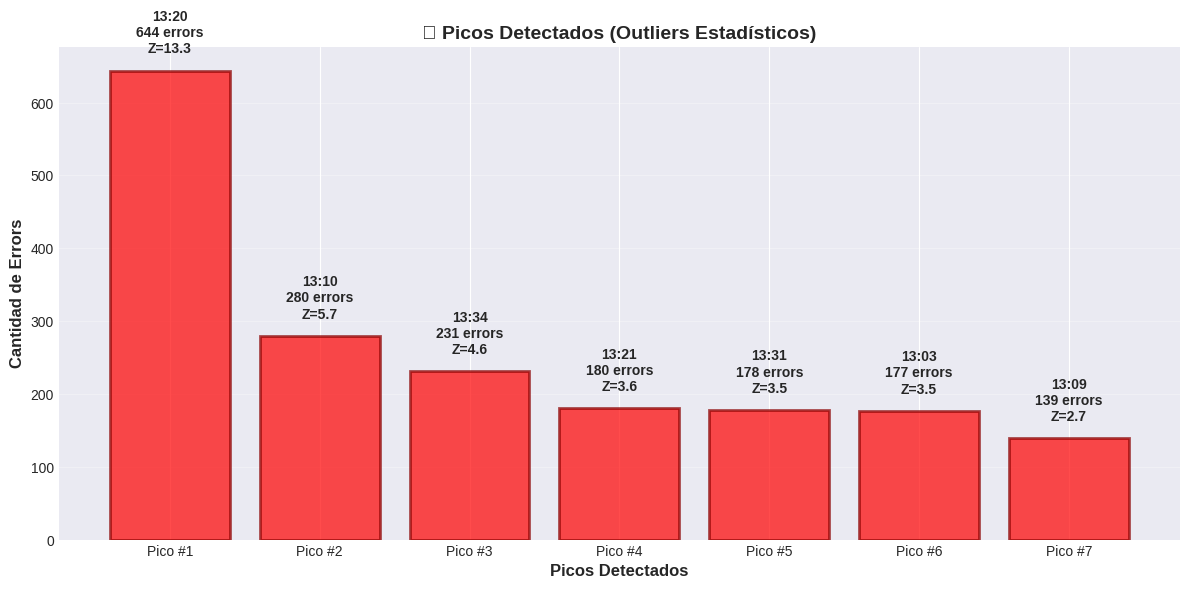

✅ Plot: ../../data/plots/01_eda_overview.png


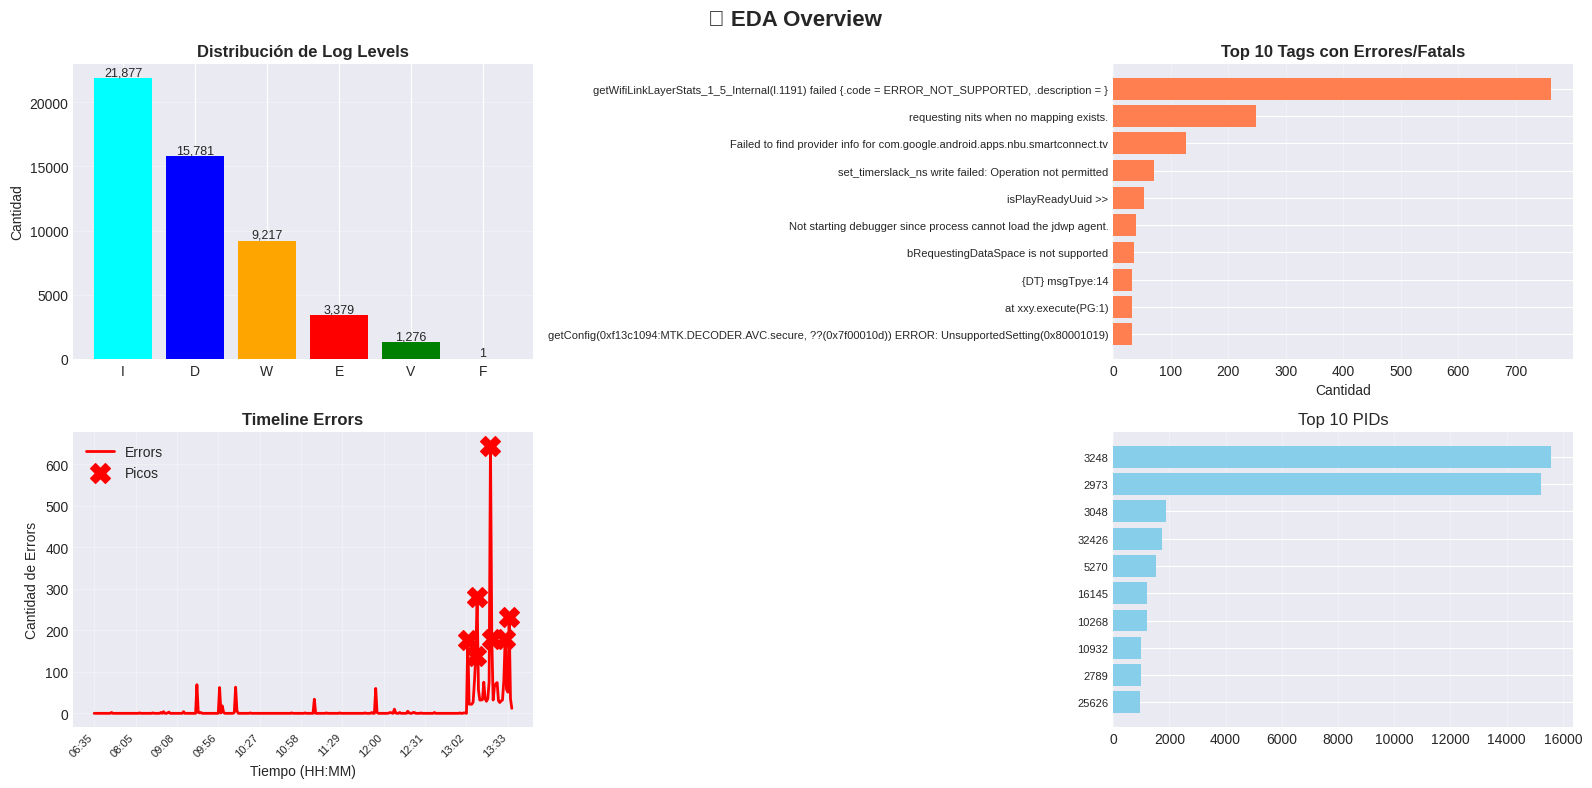


DIAGNÓSTICO

Pico detectado: 13:20
Severidad: 644 errors (Z-score: 13.3)

Componente más afectado: getWifiLinkLayerStats_1_5_Internal(l.1191) failed {.code = ERROR_NOT_SUPPORTED, .description = } (28 errors)

Componentes de Claro afectados:
  1. getWifiLinkLayerStats_1_5_Internal(l.1191) failed {.code = ERROR_NOT_SUPPORTED, .description = }: 28 errors 
  2. at xxy.execute(PG:1): 24 errors 
  3. at wlq.run(PG:74): 18 errors 
  4. at xzm.run(PG:3): 18 errors 
  5. at yhv.b(PG:8): 18 errors 

Crashes detectados: 1 fatals

Componentes con más errores (5 detectados):
  getWifiLinkLayerStats_1_5_Internal(l.1191) failed {.code = ERROR_NOT_SUPPORTED, .description = }: 761 errors (MEDIO)
    (Sin información en diccionario)
  requesting nits when no mapping exists.: 248 errors (MEDIO)
    (Sin información en diccionario)
  Failed to find provider info for com.google.android.apps.nbu.smartconnect.tv: 126 errors (MEDIO)
    (Sin información en diccionario)
  set_timerslack_ns write failed: Opera

In [32]:
def main():
    print(" QA ANÁLISIS TOP 10 + PICOS")
    print("="*80)
    
    if not Path(log_file).exists():
        print(f" No encontrado: {log_file}")
        return
    

    parsed_logs = read_log_file(log_file)
    print(f" Parseados: {len(parsed_logs):,} logs")
    
    df = pd.DataFrame(parsed_logs)
    df['is_error'] = df['level'] == 'E'
    df['is_warning'] = df['level'] == 'W'
    df['is_fatal'] = df['level'] == 'F'
    
    logs_by_minute = group_by_60s(parsed_logs)
    pids_claro = get_claro_pids(logs_by_minute)
    

    print_resumen_general(df, pids_claro)
    

    print("\n" + "="*80)
    print(" DETECCIÓN DE PICOS")
    print("="*80)
    
    picos = detect_picos(df)

    # desde inicio detección  de crash o estabilidad de errroes altos
    primer_minuto = sorted(df['time'].unique())[0]
    primer_minuto_errors = df[df['time'] == primer_minuto]['is_error'].sum()
    promedio_errors_min = df.groupby('time')['is_error'].sum().mean()

    if primer_minuto_errors > (promedio_errors_min * 0.8):
        print(f"\ Errores altos DESDE INICIO DETECTADO, problema para calcular picos")
        print(f"   Primer minuto: {primer_minuto_errors:,} errors")
        print(f"   Promedio log: {promedio_errors_min:.1f} errors/min")
        print(f"   Estado: Sistema colapsado desde inicio del log")
    
    if len(picos) > 0:
        print(f"\n {len(picos)} PICOS DETECTADOS:")
        for _, p in picos.iterrows():
            print(f"   {p['time']}: {p['errors']:,} errors (Z={p['z_score']:.1f})")
        

        print("\n" + "="*80)
        print("PARTE 1: TOP 10 GLOBAL")
        
        tops_global = generate_top_analysis(df, pids_claro, "GLOBAL")
        print_top_analysis(tops_global)
        

        print("\n" + "="*80)
        print(f"PARTE 2: TOP 10 POR PICO ({len(picos)} picos)")
        print("="*80)
        
        tops_por_pico = []
        for idx, (_, p) in enumerate(picos.iterrows(), 1):
            df_pico = df[df['time'] == p['time']]
            tops_pico = generate_top_analysis(df_pico, pids_claro, f"PICO #{idx} ({p['time']})")
            tops_por_pico.append(tops_pico)
            print(f"\n{'─'*80}")
            print(f"PICO #{idx}: {p['time']} - {p['errors']:,} errors")
            print(f"{'─'*80}")
            print_top_analysis(tops_pico, compact=True)
        


        print("\n" + "="*80)
        print("PARTE 3: TOP 10 CONSOLIDADO (suma de todos los picos)")

        print("ℹ  Nota: Este consolidado incluye TODOS los tags (Claro + Sistema Android)")
        print("   Para ver solo Claro, revisar cada pico individual\n")
        tops_consol = consolidate_tops(tops_por_pico)
        print_top_analysis(tops_consol)
        

        print("\n" + "="*80)
        print("PARTE 4: MARKET BASKET (correlaciones de negocio)")

        
        if len(picos) < 2:
            print("\nℹ  Market Basket requiere 2+ picos para encontrar correlaciones")
            print("   Solo hay 1 pico detectado en este log")
            print("   → Ejecuta con más logs para ver patrones")
        else:
            df_picos = df[df['time'].isin(picos['time'])]
            df_basket = create_basket_mejorado(df_picos, pids_claro)
            freq, rules = apply_market_basket_mejorado(df_basket)
            
            if rules is not None and len(rules) > 0:
                print_rules_mejorado(rules, top_n=10)
            else:
                print("\n  No se encontraron correlaciones significativas")
                print("   Prueba con más logs diferentes")
        

        plot_picos_detectados(picos)
        plot_overview(df, picos)
        
    else:

        print("\n✅ LOG ESTABLE - NO HAY PICOS")
        
        if MOSTRAR_TOP10_SIN_PICOS:
            tops_global = generate_top_analysis(df, pids_claro, "GLOBAL (sin picos)")
            print_top_analysis(tops_global, compact=True)
        
        plot_overview(df)
    
    diagnostico(df, picos, pids_claro)

    # PDF
    log_name = os.path.basename(log_file)  
    pdf = f"{PDFS_DIR}/{log_name.replace('.txt', '.pdf')}"
    generar_pdf(df, picos, pids_claro, log_name, pdf)

    print("\n" + "="*80)
    print("✅ COMPLETADO")
    print("="*80)


    return df
if __name__ == "__main__":
   df=  main()


